# Marketing Campaign Response Prediction

**Course:** CISD 43 – BIG DATA

### Required Packages
```
pip install numpy pandas matplotlib seaborn scikit-learn openpyxl
```

In [1]:
## import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
import warnings
warnings.filterwarnings('ignore')

## 1. Read and Clean Data
- The dataset contains 2,240 customer records with 29 columns
- `Income` has 24 missing values — we fill them with the median
- We engineer a new `Age` column from `Year_Birth` and drop columns not useful for modeling
- Categorical columns (`Education`, `Marital_Status`) are one-hot encoded for ML models

In [3]:
# Read the data
data = pd.read_excel('marketing_campaign_clean.xlsx')
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
# Check missing values and data types
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [5]:
# Check missing value counts
print('Missing values per column:')
print(data.isnull().sum()[data.isnull().sum() > 0])

Missing values per column:
Income    24
dtype: int64


In [6]:
# Fill missing Income with median
data['Income'] = data['Income'].fillna(data['Income'].median())

# Engineer Age from Year_Birth (reference year 2024)
data['Age'] = 2024 - data['Year_Birth']

# Create TotalSpend column (sum of all product spend columns)
spend_cols = ['MntWines', 'MntFruits', 'MntMeatProducts',
              'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
data['TotalSpend'] = data[spend_cols].sum(axis=1)

# Drop columns not useful for analysis
data = data.drop(['ID', 'Dt_Customer', 'Z_CostContact', 'Z_Revenue'], axis=1)

data.tail()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,TotalSpend
2235,1967,Graduation,Married,61223.0,0,1,46,709,43,182,...,5,0,0,0,0,0,0,0,57,1341
2236,1946,PhD,Together,64014.0,2,1,56,406,0,30,...,7,0,0,0,1,0,0,0,78,444
2237,1981,Graduation,Divorced,56981.0,0,0,91,908,48,217,...,6,0,1,0,0,0,0,0,43,1241
2238,1956,Master,Together,69245.0,0,1,8,428,30,214,...,3,0,0,0,0,0,0,0,68,843
2239,1954,PhD,Married,52869.0,1,1,40,84,3,61,...,7,0,0,0,0,0,0,1,70,172


In [7]:
# Round numeric columns to 2 decimal places
data = data.round(decimals=2)

# Descriptive statistics
data.describe()

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,TotalSpend
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,1968.805804,52237.975446,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,0.149107,55.194196,605.798214
std,11.984069,25037.955891,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.356274,11.984069,602.249288
min,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,28.000000,5.000000
25%,1959.000000,35538.750000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,47.000000,68.750000
50%,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,54.000000,396.000000
75%,1977.000000,68289.750000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,65.000000,1045.500000
max,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,131.000000,2525.000000


## 2. Data Visualization

#### Histogram chart to display each numeric feature distribution

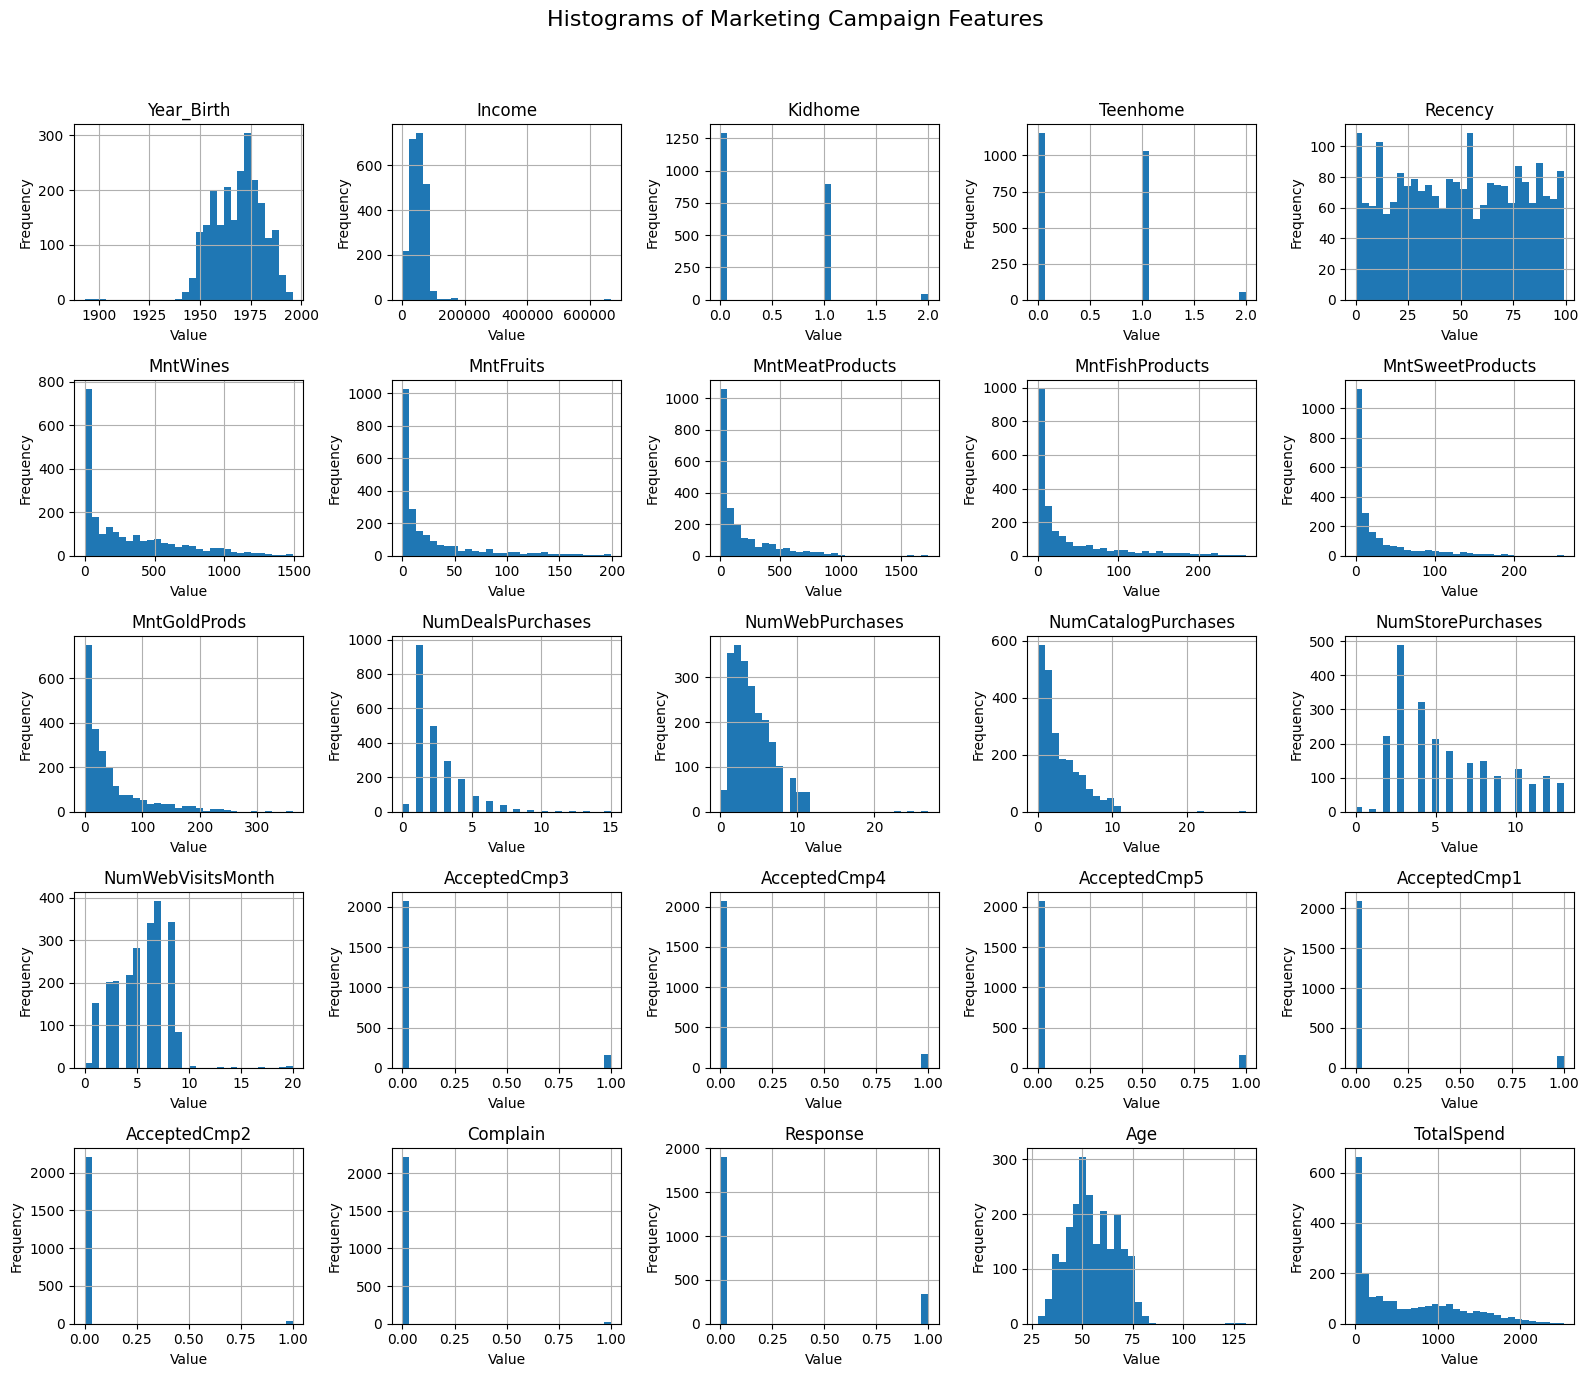

In [8]:
# Select only numeric columns for histogram
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()

axes = data[numeric_cols].hist(figsize=(16, 14), bins=30)

for ax in axes.flatten():
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.suptitle('Histograms of Marketing Campaign Features', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

#### Boxplot: Total Spend by Education Level

<Figure size 900x600 with 0 Axes>

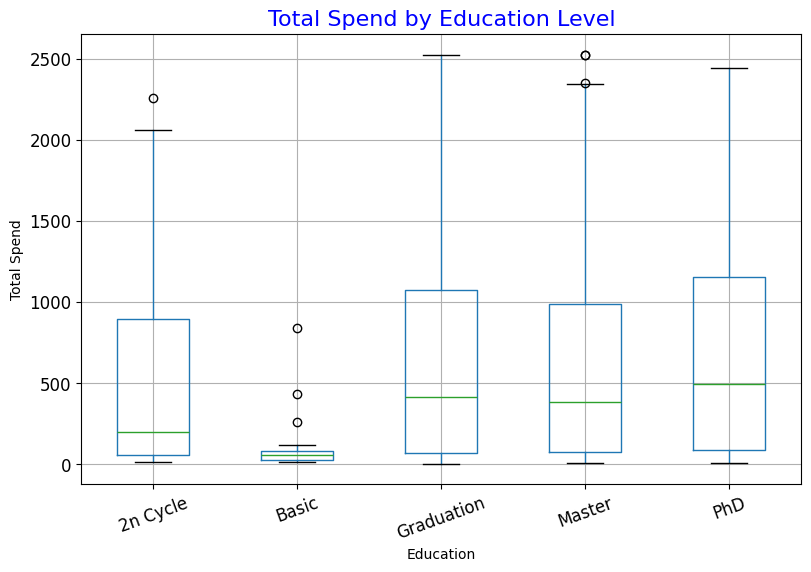

In [9]:
# Box plot — Total Spend vs Education
plt.figure(figsize=(9, 6))
data.boxplot(column='TotalSpend', by='Education', figsize=(9, 6), fontsize=12)
plt.title('Total Spend by Education Level', loc='center', color='blue', size=16)
plt.suptitle('')  # Remove default pandas title
plt.ylabel('Total Spend')
plt.xticks(rotation=20)
plt.show()

#### Correlation Heatmap

In [10]:
# Compute correlation matrix for numeric columns
corr = data[numeric_cols].corr().round(2)
corr

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,TotalSpend
Year_Birth,1.00,-0.16,0.23,-0.35,-0.02,-0.16,-0.02,-0.03,-0.04,-0.02,...,0.12,0.06,-0.06,0.01,-0.01,-0.01,-0.03,0.02,-1.00,-0.11
Income,-0.16,1.00,-0.43,0.02,-0.00,0.58,0.43,0.58,0.44,0.44,...,-0.55,-0.02,0.18,0.33,0.27,0.09,-0.03,0.13,0.16,0.66
Kidhome,0.23,-0.43,1.00,-0.04,0.01,-0.50,-0.37,-0.44,-0.39,-0.37,...,0.45,0.01,-0.16,-0.21,-0.17,-0.08,0.04,-0.08,-0.23,-0.56
Teenhome,-0.35,0.02,-0.04,1.00,0.02,0.00,-0.18,-0.26,-0.20,-0.16,...,0.13,-0.04,0.04,-0.19,-0.14,-0.02,0.00,-0.15,0.35,-0.14
Recency,-0.02,-0.00,0.01,0.02,1.00,0.02,-0.00,0.02,0.00,0.02,...,-0.02,-0.03,0.02,0.00,-0.02,-0.00,0.01,-0.20,0.02,0.02
MntWines,-0.16,0.58,-0.50,0.00,0.02,1.00,0.39,0.56,0.40,0.39,...,-0.32,0.06,0.37,0.47,0.35,0.21,-0.04,0.25,0.16,0.89
MntFruits,-0.02,0.43,-0.37,-0.18,-0.00,0.39,1.00,0.54,0.59,0.57,...,-0.42,0.01,0.01,0.22,0.19,-0.01,-0.01,0.13,0.02,0.61
MntMeatProducts,-0.03,0.58,-0.44,-0.26,0.02,0.56,0.54,1.00,0.57,0.52,...,-0.54,0.02,0.10,0.37,0.31,0.04,-0.02,0.24,0.03,0.84
MntFishProducts,-0.04,0.44,-0.39,-0.20,0.00,0.40,0.59,0.57,1.00,0.58,...,-0.45,0.00,0.02,0.20,0.26,0.00,-0.02,0.11,0.04,0.64
MntSweetProducts,-0.02,0.44,-0.37,-0.16,0.02,0.39,0.57,0.52,0.58,1.00,...,-0.42,0.00,0.03,0.26,0.24,0.01,-0.02,0.12,0.02,0.60


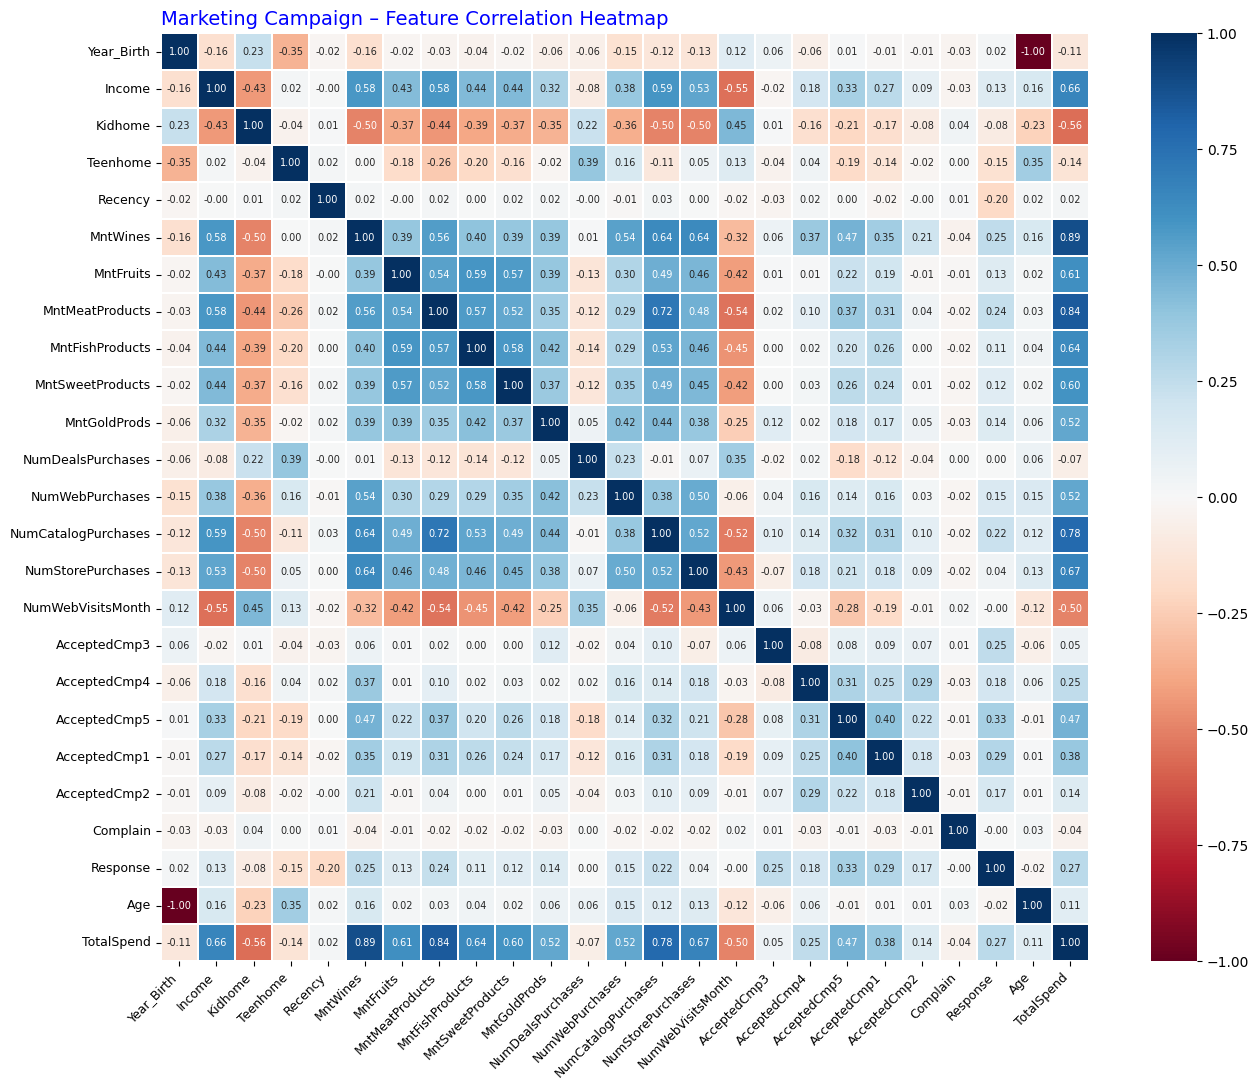

In [11]:
plt.figure(figsize=(14, 11))
sns.heatmap(corr, annot=True, linewidth=0.3, square=True,
            cmap='RdBu', fmt='.2f', annot_kws={'size': 7})
plt.xticks(fontsize=9, rotation=45, ha='right')
plt.yticks(fontsize=9)
plt.title('Marketing Campaign – Feature Correlation Heatmap',
          loc='left', color='blue', size=14)
plt.tight_layout()
plt.show()

#### Bar Chart: Campaign Acceptance Rates

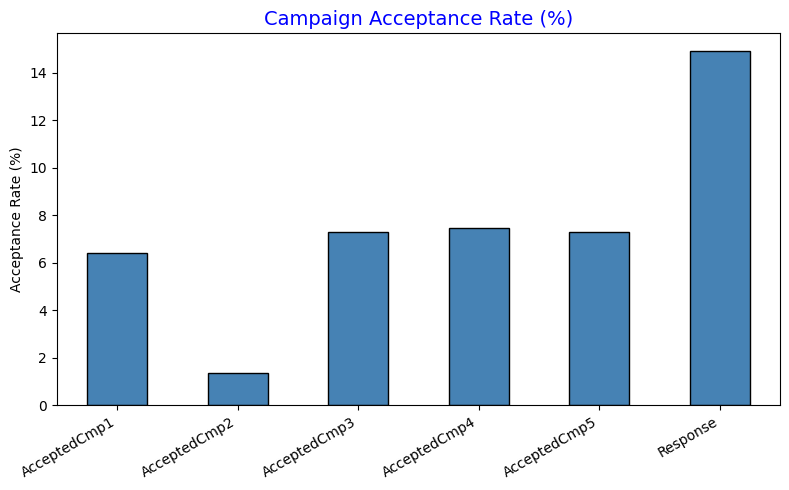

In [12]:
# Campaign acceptance rates
cmp_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
            'AcceptedCmp4', 'AcceptedCmp5', 'Response']
acceptance_rate = data[cmp_cols].mean() * 100

plt.figure(figsize=(8, 5))
acceptance_rate.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Campaign Acceptance Rate (%)', fontsize=14, color='blue')
plt.ylabel('Acceptance Rate (%)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### Methodology

1. **Big Data Methodology**
   - Use `pandas` to load and clean the Excel dataset, filling missing `Income` values with the median
   - Use `matplotlib` and `seaborn` for exploratory visualizations (histograms, boxplots, heatmaps)
   - Use `sklearn` `train_test_split` to split data (80/20) for training and testing
   - Use `StandardScaler` to normalize features before KNN
   - Use `KNeighborsClassifier` with `classification_report` and `ConfusionMatrixDisplay` to classify whether a customer will respond to a campaign

2. **Models Used**
   - **KNN (K-Nearest Neighbors)**: Classifies `Response` (0 or 1) by finding the *k* closest training samples in the standardized feature space using Euclidean distance

## Your Code Starts Here

### KNN Classification
**Target:** `Response` (0 = did not respond, 1 = responded to campaign)

#### Standardize the Variables
Using `StandardScaler` from sklearn to rescale all features to the same scale (mean=0, std=1).

In [13]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Create scaler instance
scaler = StandardScaler()

In [14]:
# Use full numeric data; Response is our classification target
knn_data = data[numeric_cols].copy()

# Fit scaler on feature columns only (excluding Response)
feature_cols = [c for c in knn_data.columns if c != 'Response']
scaler.fit(knn_data[feature_cols])
print('Scaler fitted.')

Scaler fitted.


In [15]:
# Transform features
scaled_features = scaler.transform(knn_data[feature_cols])
df_feature = pd.DataFrame(scaled_features, columns=feature_cols)
df_feature.head()

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Age,TotalSpend
0,-0.985345,0.235696,-0.825218,-0.929894,0.307039,0.983781,1.551577,1.679702,2.462147,1.476500,...,-0.550785,0.693904,-0.28014,-0.28383,-0.28014,-0.262111,-0.11651,-0.097282,0.985345,1.679417
1,-1.235733,-0.235454,1.032559,0.906934,-0.383664,-0.870479,-0.636301,-0.713225,-0.650449,-0.631503,...,-1.166125,-0.130463,-0.28014,-0.28383,-0.28014,-0.262111,-0.11651,-0.097282,1.235733,-0.961275
2,-0.317643,0.773999,-0.825218,-0.929894,-0.798086,0.362723,0.570804,-0.177032,1.345274,-0.146905,...,1.295237,-0.542647,-0.28014,-0.28383,-0.28014,-0.262111,-0.11651,-0.097282,0.317643,0.282673
3,1.268149,-1.022355,1.032559,-0.929894,-0.798086,-0.870479,-0.560857,-0.651187,-0.503974,-0.583043,...,-0.550785,0.281720,-0.28014,-0.28383,-0.28014,-0.262111,-0.11651,-0.097282,-1.268149,-0.918094
4,1.017761,0.241888,1.032559,-0.929894,1.550305,-0.389085,0.419916,-0.216914,0.155164,-0.001525,...,0.064556,-0.130463,-0.28014,-0.28383,-0.28014,-0.262111,-0.11651,-0.097282,-1.017761,-0.305254


#### Prepare X and y for KNN

In [16]:
# X = all scaled features; y = Response (binary: 0 or 1)
dfx = df_feature.copy()
dfy = knn_data['Response'].reset_index(drop=True)

print('Class distribution:')
print(dfy.value_counts())

Class distribution:
Response
0    1906
1     334
Name: count, dtype: int64


#### Train/Test Split for KNN

In [17]:
from sklearn.model_selection import train_test_split

X = dfx
y = dfy

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=101)

In [18]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [19]:
# Train KNN with k=5 and Euclidean distance (p=2)
k = 5
knn = KNeighborsClassifier(n_neighbors=k, p=2)
knn.fit(X_train, y_train)
print('KNN model fitted.')

KNN model fitted.



Classification Report
               precision    recall  f1-score   support

           0       0.92      0.97      0.94       386
           1       0.68      0.45      0.54        62

    accuracy                           0.90       448
   macro avg       0.80      0.71      0.74       448
weighted avg       0.88      0.90      0.89       448

Confusion Matrix:
 [[373  13]
 [ 34  28]] 



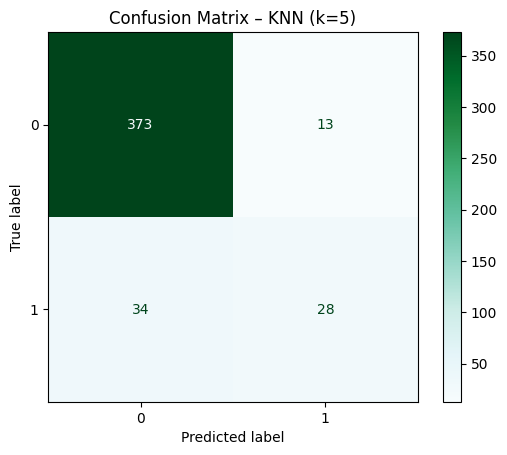

In [20]:
# Predict and evaluate
y_pred = knn.predict(X_test)
cm = confusion_matrix(y_test, y_pred, labels=knn.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn.classes_)

print('\nClassification Report\n', classification_report(y_test, y_pred))
print('Confusion Matrix:\n', cm, '\n')

disp.plot(cmap=plt.cm.BuGn)
plt.title('Confusion Matrix – KNN (k=5)')
plt.show()

### Using Accuracy to Find Optimal k

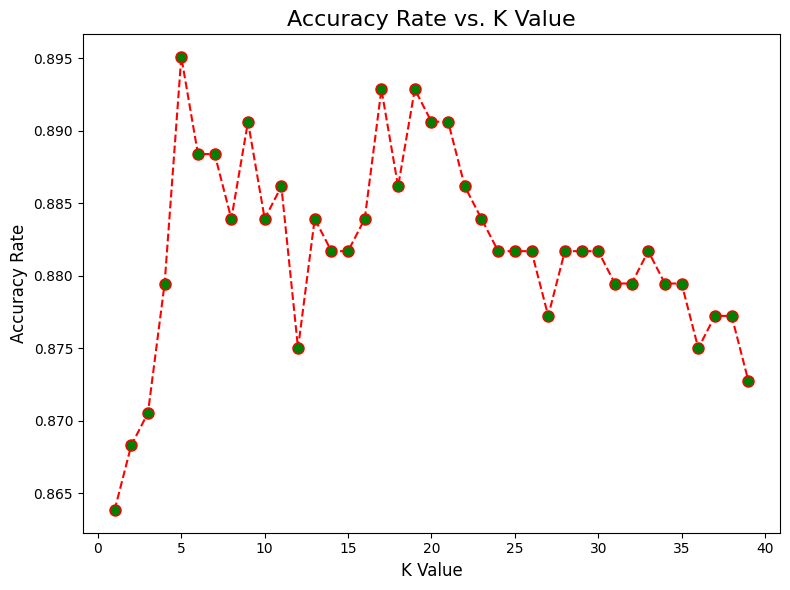

Maximum Accuracy: 0.8951  at  K = 5


In [21]:
from sklearn import metrics

acc = []
for i in range(1, 40):
    neigh = KNeighborsClassifier(n_neighbors=i).fit(X_train, y_train)
    yhat = neigh.predict(X_test)
    acc.append(metrics.accuracy_score(y_test, yhat))

plt.figure(figsize=(8, 6))
plt.plot(range(1, 40), acc, color='red', linestyle='dashed',
         marker='o', markerfacecolor='green', markersize=8)
plt.title('Accuracy Rate vs. K Value', fontsize=16)
plt.xlabel('K Value', fontsize=12)
plt.ylabel('Accuracy Rate', fontsize=12)
plt.tight_layout()
plt.show()

best_k = acc.index(max(acc)) + 1
print(f'Maximum Accuracy: {max(acc):.4f}  at  K = {best_k}')

### Conclusions

* From `describe()`, the average total customer spend is driven heavily by wine and meat purchases.
* The boxplot shows that **PhD and Master degree holders** tend to spend more than customers with basic education.
* The correlation heatmap confirms that **Income** and **catalog purchases** are most strongly correlated with total spend, which is consistent with higher-income customers spending more.
* Campaign acceptance rates are low across all five campaigns (< 15%), with the final `Response` column being the highest.
* **KNN Classification** classifies `Response` (0 vs 1). Because the dataset is imbalanced (~85% non-responders), accuracy can be misleading — precision and recall on class 1 are more informative metrics.
* The optimal k found by the accuracy loop provides the best balance between bias and variance for this dataset.

### References
- Scikit-learn documentation: https://scikit-learn.org
- KNN optimal k: https://towardsdatascience.com/how-to-find-the-optimal-value-of-k-in-knn-35d936e554eb
- Marketing Campaign Dataset (Kaggle: https://www.kaggle.com/datasets/rodsaldanha/arketing-campaign?resource=download)
- Classmate's Project: https://github.com/tchao168/CISD43/blob/main/CISD%2043_FinalCode1_Houseing.ipynb?short_path=a7f66fc
- Professor Hernandez

In [22]:
# End of Project